# Notebook 4: Pandas Basics
### ML Skills Refresh Curriculum — Module 4 of 30
#### Module 2: The Pandas Masterclass — Part 1 of 3

---

## 🎯 Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | What a DataFrame actually *is* | Understanding the data structure prevents shape bugs later |
| 2 | `Series` vs `DataFrame` | Almost every Pandas operation returns one or the other |
| 3 | Creating DataFrames | From dicts, lists, and NumPy arrays — three routes you'll use constantly |
| 4 | Basic inspection (`head`, `info`, `describe`) | First things you run on any new dataset |
| 5 | Reading & writing CSVs | How real data enters and leaves your pipeline |

---

> **Dataset Context:** We use a hand-crafted **Employee Directory** for a fictional company — 10 employees with names, departments, ages, salaries, and full-time status. It is small enough to print in full, so you can always verify what Pandas is doing against the raw numbers.

---
## Section 1 — What Is a DataFrame? (The Mental Model)

### 📖 The Logic — Before Any Code

A **DataFrame** is Pandas' central data structure. Conceptually it is a **2-D labelled table** — like a spreadsheet — with rows and columns. But under the hood it is really just a **dictionary of NumPy arrays**:

```
{
  "name"       : np.array(["Alice", "Bob", "Carol", ...]),   # column 1
  "department" : np.array(["Eng",   "HR",  "Eng",  ...]),   # column 2
  "salary"     : np.array([75000,   52000, 91000,  ...]),   # column 3
}
```

Every **column** is a single NumPy array, which Pandas calls a **Series**. The DataFrame wraps them together, aligns them on a shared **index** (row labels), and adds powerful querying, grouping, and I/O methods on top.

---

### The Three Key Components

```
           name    department   salary          ← Column labels (axis=1)
index  ↓
  0    │  Alice       Eng       75000
  1    │  Bob         HR        52000
  2    │  Carol       Eng       91000
       │
  ↑ Row index (axis=0) — default is 0, 1, 2 … (integers)
```

| Term | What it is | Analogy |
|------|-----------|------|
| **Index** | Row labels — an array of identifiers | Spreadsheet row numbers |
| **Columns** | Column labels — names for each Series | Spreadsheet column headers |
| **Values** | The underlying NumPy array of data | The cells of the spreadsheet |

---

### Series vs DataFrame

| | `pd.Series` | `pd.DataFrame` |
|-|------------|---------------|
| Dimensions | 1-D | 2-D |
| Analogy | A single spreadsheet column | The whole spreadsheet |
| Has column name? | It *is* the column | Has many column names |
| Selecting one column from a DF | Returns a Series | — |

In practice: every time you select **one column** from a DataFrame, you get back a **Series**. Every time you select **multiple columns**, you get back a **DataFrame**.

In [1]:
import pandas as pd       # the Pandas library — aliased 'pd' by universal convention
import numpy as np        # NumPy for supplementary array operations
import matplotlib.pyplot as plt   # for visualisations in the final section

# Print library versions — good habit for reproducibility
print(f"Pandas  version: {pd.__version__}")
print(f"NumPy   version: {np.__version__}")

Pandas  version: 2.2.2
NumPy   version: 2.0.2


---
## Section 2 — `pd.Series`: The Building Block

### 📖 The Logic

A **Series** is a 1-D array with a labelled index. It is always homogeneous — every element has the same dtype (just like a NumPy array). Think of it as a single column ripped out of a spreadsheet, with the row numbers still attached.

**Key attributes:**
- `.values` — the underlying NumPy array
- `.index` — the row labels
- `.dtype` — the data type of the stored values
- `.name` — the column name (set when extracted from a DataFrame)

In [2]:
# ── Creating a Series from a plain Python list ────────────────────────────────
# Pandas automatically assigns an integer index (0, 1, 2, …)
salaries = pd.Series([75000, 52000, 91000, 68000, 83000],
                     name="salary")   # 'name' will become the column header in a DF

print("── salaries Series ──")
print(salaries)
print(f"\ndtype : {salaries.dtype}")
print(f"shape : {salaries.shape}")   # (5,) — a 1-D array of 5 elements

# ── Creating a Series with a custom string index ──────────────────────────────
# Useful when rows represent named entities (employees, countries, etc.)
salaries_named = pd.Series(
    [75000, 52000, 91000, 68000, 83000],
    index=["Alice", "Bob", "Carol", "David", "Eva"],  # custom row labels
    name="salary"
)

print("\n── salaries_named Series (custom index) ──")
print(salaries_named)

# ── Accessing elements — same syntax as a dictionary ─────────────────────────
print(f"\nBob's salary   : £{salaries_named['Bob']:,}")
print(f"Carol's salary : £{salaries_named['Carol']:,}")

── salaries Series ──
0    75000
1    52000
2    91000
3    68000
4    83000
Name: salary, dtype: int64

dtype : int64
shape : (5,)

── salaries_named Series (custom index) ──
Alice    75000
Bob      52000
Carol    91000
David    68000
Eva      83000
Name: salary, dtype: int64

Bob's salary   : £52,000
Carol's salary : £91,000


In [3]:
# ── Series arithmetic is vectorised — operates element-wise like NumPy ─────────
# Example: apply a 10% pay rise to all salaries
risen = salaries_named * 1.10    # scalar broadcasts across all elements

print("── After 10% rise ──")
print(risen.round(0).astype(int))   # round to nearest pound, cast to int

# ── Boolean masking: filter elements meeting a condition ─────────────────────
# Returns a boolean Series where each element is True / False
high_earners_mask = salaries_named > 70000
print("\n── Boolean mask (salary > £70k) ──")
print(high_earners_mask)

# Apply the mask to filter the Series — only True rows are returned
print("\n── High earners only ──")
print(salaries_named[high_earners_mask])

# ── Useful Series summary methods ─────────────────────────────────────────────
print(f"\nMean salary  : £{salaries_named.mean():,.0f}")
print(f"Median salary: £{salaries_named.median():,.0f}")
print(f"Max salary   : £{salaries_named.max():,}")

── After 10% rise ──
Alice     82500
Bob       57200
Carol    100100
David     74800
Eva       91300
Name: salary, dtype: int64

── Boolean mask (salary > £70k) ──
Alice     True
Bob      False
Carol     True
David    False
Eva       True
Name: salary, dtype: bool

── High earners only ──
Alice    75000
Carol    91000
Eva      83000
Name: salary, dtype: int64

Mean salary  : £73,800
Median salary: £75,000
Max salary   : £91,000


---
## Section 3 — Creating a DataFrame

### 📖 The Logic

There are three common routes to creating a DataFrame. In real ML projects you'll encounter all three:

| Route | When you use it |
|-------|-----------------|
| **From a dict of lists** | Building a dataset directly in code (this notebook) |
| **From a list of dicts** | Parsing API responses, JSON records |
| **From a NumPy array** | Converting a processed feature matrix back to a labelled table |

All three produce the same result — a 2-D labelled table.

In [4]:
# ══════════════════════════════════════════════════════════════════
#  Route 1: DataFrame from a dictionary of lists
#  Keys   → column names
#  Values → one list per column (all must be the same length)
# ══════════════════════════════════════════════════════════════════

employee_dict = {
    "name"       : ["Alice", "Bob", "Carol", "David", "Eva",
                    "Frank", "Grace", "Hank", "Iris", "Jake"],
    "department" : ["Engineering", "HR", "Engineering", "Marketing", "Engineering",
                    "HR", "Marketing", "Engineering", "HR", "Marketing"],
    "age"        : [31, 45, 29, 38, 34,
                    52, 27, 41, 36, 30],
    "salary"     : [75000, 52000, 91000, 68000, 83000,
                    55000, 61000, 78000, 49000, 64000],
    "full_time"  : [True, True, True, False, True,
                    False, True, True, True, False],
}

# pd.DataFrame() wraps the dict — each list becomes one column Series
df = pd.DataFrame(employee_dict)

print(f"Type  : {type(df)}")
print(f"Shape : {df.shape}   ← (rows, columns)")
print()
print(df)    # print the full DataFrame — only practical because it is small

Type  : <class 'pandas.core.frame.DataFrame'>
Shape : (10, 5)   ← (rows, columns)

    name   department  age  salary  full_time
0  Alice  Engineering   31   75000       True
1    Bob           HR   45   52000       True
2  Carol  Engineering   29   91000       True
3  David    Marketing   38   68000      False
4    Eva  Engineering   34   83000       True
5  Frank           HR   52   55000      False
6  Grace    Marketing   27   61000       True
7   Hank  Engineering   41   78000       True
8   Iris           HR   36   49000       True
9   Jake    Marketing   30   64000      False


In [5]:
# ══════════════════════════════════════════════════════════════════
#  Route 2: DataFrame from a list of dictionaries
#  Each dict is one ROW; keys become column names.
#  Pandas aligns on key names — missing keys → NaN automatically.
# ══════════════════════════════════════════════════════════════════

records = [
    {"name": "Lena", "department": "Engineering", "age": 28, "salary": 88000, "full_time": True},
    {"name": "Mike", "department": "Marketing",   "age": 44, "salary": 71000, "full_time": True},
    {"name": "Nina", "department": "HR",           "age": 33},   # salary and full_time missing
]

df_records = pd.DataFrame(records)   # Pandas fills missing values with NaN

print("── From list-of-dicts (note NaN for Nina's missing fields) ──")
print(df_records)
print(f"\ndtype of salary column: {df_records['salary'].dtype}")   # float64 because of NaN

── From list-of-dicts (note NaN for Nina's missing fields) ──
   name   department  age   salary full_time
0  Lena  Engineering   28  88000.0      True
1  Mike    Marketing   44  71000.0      True
2  Nina           HR   33      NaN       NaN

dtype of salary column: float64


In [6]:
# ══════════════════════════════════════════════════════════════════
#  Route 3: DataFrame from a NumPy array
#  Useful when returning from a preprocessing step that produces
#  a plain NumPy matrix and you want column labels back.
# ══════════════════════════════════════════════════════════════════

# Simulate a (4 × 3) feature matrix produced by a NumPy pipeline
feature_matrix = np.array([
    [31, 75000, 1],
    [45, 52000, 1],
    [29, 91000, 1],
    [38, 68000, 0],
])   # shape (4, 3) — dtype int64

df_numpy = pd.DataFrame(
    feature_matrix,
    columns=["age", "salary", "full_time"],   # provide column names explicitly
    index=["Alice", "Bob", "Carol", "David"]  # optional: custom row index
)

print("── From NumPy array ──")
print(df_numpy)

# Show that the underlying values ARE a NumPy array
print(f"\n.values type : {type(df_numpy.values)}")
print(f".values dtype: {df_numpy.values.dtype}")
print("Raw values:\n", df_numpy.values)

── From NumPy array ──
       age  salary  full_time
Alice   31   75000          1
Bob     45   52000          1
Carol   29   91000          1
David   38   68000          0

.values type : <class 'numpy.ndarray'>
.values dtype: int64
Raw values:
 [[   31 75000     1]
 [   45 52000     1]
 [   29 91000     1]
 [   38 68000     0]]


---
## Section 4 — Selecting Columns: Series vs DataFrame

### 📖 The Logic

This is the most important shape rule in Pandas:

| Selector syntax | What you get back | Why |
|----------------|------------------|-----|
| `df["column"]` | **Series** | Single column → 1-D |
| `df[["col1", "col2"]]` | **DataFrame** | Multiple columns → 2-D |

The double-bracket syntax `df[[...]]` passes a **list** of column names. That extra pair of brackets is not a typo — it is what tells Pandas to return a 2-D result.

In [7]:
# ── Select ONE column → returns a Series ──────────────────────────────────────
salary_series = df["salary"]        # single string inside single brackets
print(f"Type of df['salary']      : {type(salary_series)}")
print(f"Shape                     : {salary_series.shape}   ← 1-D")
print(salary_series)

print()

# ── Select MULTIPLE columns → returns a DataFrame ─────────────────────────────
subset_df = df[["name", "department", "salary"]]   # list of column names
print(f"Type of df[['name','department','salary']] : {type(subset_df)}")
print(f"Shape                                      : {subset_df.shape}   ← 2-D")
print(subset_df)

Type of df['salary']      : <class 'pandas.core.series.Series'>
Shape                     : (10,)   ← 1-D
0    75000
1    52000
2    91000
3    68000
4    83000
5    55000
6    61000
7    78000
8    49000
9    64000
Name: salary, dtype: int64

Type of df[['name','department','salary']] : <class 'pandas.core.frame.DataFrame'>
Shape                                      : (10, 3)   ← 2-D
    name   department  salary
0  Alice  Engineering   75000
1    Bob           HR   52000
2  Carol  Engineering   91000
3  David    Marketing   68000
4    Eva  Engineering   83000
5  Frank           HR   55000
6  Grace    Marketing   61000
7   Hank  Engineering   78000
8   Iris           HR   49000
9   Jake    Marketing   64000


In [8]:
# ── Accessing individual column attributes ────────────────────────────────────
print("Column names :", df.columns.tolist())   # .columns is an Index object; .tolist() → list
print("Index        :", df.index.tolist())      # default RangeIndex: [0,1,...,9]
print("Shape        :", df.shape)               # (10, 5)
print("dtypes:\n",      df.dtypes)              # dtype of every column

Column names : ['name', 'department', 'age', 'salary', 'full_time']
Index        : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Shape        : (10, 5)
dtypes:
 name          object
department    object
age            int64
salary         int64
full_time       bool
dtype: object


---
## Section 5 — Basic Inspection Methods

### 📖 The Logic

These are the **first five things you do** every time you load a new dataset into Pandas. Run them in order — they give you a rapid picture of what the data looks like before you write a single line of cleaning or analysis code.

| Method | What it shows |
|--------|---------------|
| `df.head(n)` | First `n` rows (default 5) — a quick visual sanity check |
| `df.tail(n)` | Last `n` rows — check the end of the data too |
| `df.info()` | Column names, non-null counts, dtypes, memory usage |
| `df.describe()` | Count, mean, std, min, quartiles, max for numeric columns |
| `df.shape` | (rows, columns) — the simplest size check |

In [9]:
# ── df.head(n): show the first n rows ─────────────────────────────────────────
# Default n=5; for very wide DataFrames, head() is safer than printing the whole thing
print("── df.head(3) ──")
print(df.head(3))    # first 3 rows

print()

# ── df.tail(n): show the last n rows ──────────────────────────────────────────
# Useful to confirm the data didn't get truncated or have trailing garbage
print("── df.tail(3) ──")
print(df.tail(3))    # last 3 rows

── df.head(3) ──
    name   department  age  salary  full_time
0  Alice  Engineering   31   75000       True
1    Bob           HR   45   52000       True
2  Carol  Engineering   29   91000       True

── df.tail(3) ──
   name   department  age  salary  full_time
7  Hank  Engineering   41   78000       True
8  Iris           HR   36   49000       True
9  Jake    Marketing   30   64000      False


In [10]:
# ── df.info(): the most important inspection method ───────────────────────────
# Shows:
#   • Number of rows (RangeIndex)
#   • Column names in order
#   • Count of NON-NULL values per column  ← flags missing data immediately
#   • dtype of each column                 ← flags wrongly-typed columns
#   • Memory usage

print("── df.info() ──")
df.info()

# Reading the output:
#   'non-null count' < total rows → there are NaN values in that column
#   dtype 'object'  → Pandas stores strings as 'object' dtype
#   dtype 'bool'    → full_time is correctly inferred as boolean

── df.info() ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        10 non-null     object
 1   department  10 non-null     object
 2   age         10 non-null     int64 
 3   salary      10 non-null     int64 
 4   full_time   10 non-null     bool  
dtypes: bool(1), int64(2), object(2)
memory usage: 462.0+ bytes


In [11]:
# ── df.describe(): summary statistics for numeric columns ─────────────────────
# Automatically skips non-numeric columns (name, department, full_time)
# For each numeric column it shows:
#   count — number of non-null values
#   mean  — arithmetic average
#   std   — standard deviation (spread of the data)
#   min   — smallest value
#   25%   — 25th percentile (Q1)
#   50%   — median (Q2)
#   75%   — 75th percentile (Q3)
#   max   — largest value

print("── df.describe() ──")
print(df.describe())

# ── To include boolean / object columns, pass include='all' ───────────────────
print("\n── df.describe(include='all') ──")
print(df.describe(include="all"))
# For non-numeric columns you get count, unique, top (most frequent), freq

── df.describe() ──
             age        salary
count  10.000000     10.000000
mean   36.300000  67600.000000
std     7.888811  13953.892328
min    27.000000  49000.000000
25%    30.250000  56500.000000
50%    35.000000  66000.000000
75%    40.250000  77250.000000
max    52.000000  91000.000000

── df.describe(include='all') ──
         name   department        age        salary full_time
count      10           10  10.000000     10.000000        10
unique     10            3        NaN           NaN         2
top     Alice  Engineering        NaN           NaN      True
freq        1            4        NaN           NaN         7
mean      NaN          NaN  36.300000  67600.000000       NaN
std       NaN          NaN   7.888811  13953.892328       NaN
min       NaN          NaN  27.000000  49000.000000       NaN
25%       NaN          NaN  30.250000  56500.000000       NaN
50%       NaN          NaN  35.000000  66000.000000       NaN
75%       NaN          NaN  40.250000  77250.00

In [12]:
# ── Bonus inspection: value_counts() on a categorical column ─────────────────
# Returns a Series counting how many times each unique value appears.
# Essential for understanding class balance in a target column.

dept_counts = df["department"].value_counts()   # Series: unique value → count
print("── Department counts ──")
print(dept_counts)

# ── nunique(): how many distinct values are in a column? ─────────────────────
print(f"\nUnique departments : {df['department'].nunique()}")
print(f"Unique ages        : {df['age'].nunique()}")

# ── isnull().sum(): count missing values per column ──────────────────────────
# Returns 0 for our clean dataset — but this is a critical check on real data
print("\n── Missing values per column ──")
print(df.isnull().sum())

── Department counts ──
department
Engineering    4
HR             3
Marketing      3
Name: count, dtype: int64

Unique departments : 3
Unique ages        : 10

── Missing values per column ──
name          0
department    0
age           0
salary        0
full_time     0
dtype: int64


---
## Section 6 — The Index: Pandas' Row Address System

### 📖 The Logic

Every DataFrame and Series has an **Index** — a set of row labels. By default Pandas assigns a `RangeIndex` (0, 1, 2, …), but you can set any column as the index. The index becomes the fast lookup key: like a Python dictionary key, but for rows.

**Why it matters in ML:** After a train/test split, the row indices from the original DataFrame are preserved in the subsets. If you then reset operations against position (0, 1, 2, …) you may get KeyErrors. Knowing how to reset or use the index prevents subtle bugs.

In [13]:
# ── Default integer RangeIndex ────────────────────────────────────────────────
print("Default index:", df.index.tolist())

# ── Set a column as the index using set_index() ───────────────────────────────
# inplace=False (default) → returns a new DataFrame, does not modify df
df_named = df.set_index("name")     # 'name' column becomes the row label
print("\n── df with 'name' as index ──")
print(df_named.head())

# Now rows are addressed by name string instead of integer
print("\nAlice's row:")
print(df_named.loc["Alice"])    # .loc uses label-based indexing

# ── Reset back to integer index ───────────────────────────────────────────────
# drop=False → the old index ('name') is pushed back into a regular column
df_reset = df_named.reset_index(drop=False)
print("\n── After reset_index() — 'name' is a column again ──")
print(df_reset.head(3))

Default index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

── df with 'name' as index ──
        department  age  salary  full_time
name                                      
Alice  Engineering   31   75000       True
Bob             HR   45   52000       True
Carol  Engineering   29   91000       True
David    Marketing   38   68000      False
Eva    Engineering   34   83000       True

Alice's row:
department    Engineering
age                    31
salary              75000
full_time            True
Name: Alice, dtype: object

── After reset_index() — 'name' is a column again ──
    name   department  age  salary  full_time
0  Alice  Engineering   31   75000       True
1    Bob           HR   45   52000       True
2  Carol  Engineering   29   91000       True


---
## Section 7 — Reading & Writing CSV Files

### 📖 The Logic

In the real world, almost every ML project starts with `pd.read_csv()` — loading data from a file into a DataFrame. At the end of preprocessing, you often save the cleaned data back out with `df.to_csv()` so the next stage of the pipeline can consume it.

**`pd.read_csv()` — the most-used Pandas function:**

| Parameter | Default | What it does |
|-----------|---------|-------------|
| `filepath_or_buffer` | — | Path to the CSV file (required) |
| `sep` | `','` | Column delimiter character |
| `header` | `0` | Row number to use as column names |
| `index_col` | `None` | Column to use as the row index |
| `usecols` | `None` | List of columns to load (skip the rest) |
| `dtype` | Inferred | Force-cast specific columns to a dtype |
| `na_values` | Standard set | Extra strings to treat as NaN |
| `nrows` | All | Read only the first N rows (useful for huge files) |

> **Note:** The cells below first demonstrate the concept by saving our `df` to a temporary path and then reading it back — so the round-trip runs perfectly top-to-bottom. After that, we show the general pattern for reading an *external* file inside a `try/except` guard.

In [14]:
import os   # standard library — used to build file paths and check file existence

# ── df.to_csv(): save a DataFrame to a CSV file ──────────────────────────────
# index=False → do NOT write the integer row index as a column (almost always what you want)
save_path = "/tmp/employees.csv"   # temporary path that always exists on Linux/Mac

df.to_csv(
    save_path,      # destination file path
    index=False,    # omit the 0,1,2,... row index from the file
    encoding="utf-8"  # explicit encoding prevents issues on Windows machines
)

print(f"File saved to : {save_path}")
print(f"File exists   : {os.path.exists(save_path)}")
print(f"File size     : {os.path.getsize(save_path)} bytes")

# ── Peek at the raw file contents ────────────────────────────────────────────
with open(save_path, "r") as f:      # open the file in read mode
    raw_lines = f.readlines()         # read all lines into a list

print("\nFirst 4 lines of the CSV file:")
for line in raw_lines[:4]:            # print lines 0-3 (header + first 3 data rows)
    print(" ", line.rstrip())         # .rstrip() removes trailing newline characters

File saved to : /tmp/employees.csv
File exists   : True
File size     : 320 bytes

First 4 lines of the CSV file:
  name,department,age,salary,full_time
  Alice,Engineering,31,75000,True
  Bob,HR,45,52000,True
  Carol,Engineering,29,91000,True


In [15]:
# ── pd.read_csv(): load the file we just saved back into a DataFrame ──────────
df_loaded = pd.read_csv(
    save_path,         # path to the CSV we saved above
    encoding="utf-8"   # match the encoding used when saving
)

print("── Loaded DataFrame (from CSV round-trip) ──")
print(df_loaded)

# ── Verify the round-trip preserved the data exactly ─────────────────────────
print(f"\nShapes match  : {df.shape} == {df_loaded.shape}  →  {df.shape == df_loaded.shape}")
print(f"Values equal  : {df.equals(df_loaded)}")

── Loaded DataFrame (from CSV round-trip) ──
    name   department  age  salary  full_time
0  Alice  Engineering   31   75000       True
1    Bob           HR   45   52000       True
2  Carol  Engineering   29   91000       True
3  David    Marketing   38   68000      False
4    Eva  Engineering   34   83000       True
5  Frank           HR   52   55000      False
6  Grace    Marketing   27   61000       True
7   Hank  Engineering   41   78000       True
8   Iris           HR   36   49000       True
9   Jake    Marketing   30   64000      False

Shapes match  : (10, 5) == (10, 5)  →  True
Values equal  : True


In [16]:
# ── Common read_csv parameters demonstrated on our own file ──────────────────

# usecols → load only specific columns (avoids memory waste on wide datasets)
df_subset = pd.read_csv(save_path, usecols=["name", "department", "salary"])
print("── usecols=['name','department','salary'] ──")
print(df_subset.head(3))

# nrows → load only the first N rows (fast way to sample a huge file)
df_sample = pd.read_csv(save_path, nrows=4)
print(f"\n── nrows=4  →  shape {df_sample.shape} ──")
print(df_sample)

# index_col → use 'name' column as the row index on load
df_indexed = pd.read_csv(save_path, index_col="name")
print(f"\n── index_col='name'  →  index type: {type(df_indexed.index).__name__} ──")
print(df_indexed.head(3))

── usecols=['name','department','salary'] ──
    name   department  salary
0  Alice  Engineering   75000
1    Bob           HR   52000
2  Carol  Engineering   91000

── nrows=4  →  shape (4, 5) ──
    name   department  age  salary  full_time
0  Alice  Engineering   31   75000       True
1    Bob           HR   45   52000       True
2  Carol  Engineering   29   91000       True
3  David    Marketing   38   68000      False

── index_col='name'  →  index type: Index ──
        department  age  salary  full_time
name                                      
Alice  Engineering   31   75000       True
Bob             HR   45   52000       True
Carol  Engineering   29   91000       True


In [17]:
# ════════════════════════════════════════════════════════════════════
#  GENERAL PATTERN — Reading an external CSV file
#  Wrapped in try/except so this notebook runs cleanly even when the
#  external file does not exist (e.g. when running for the first time).
# ════════════════════════════════════════════════════════════════════

EXTERNAL_CSV_PATH = "data/employees_external.csv"   # ← replace with your real path

try:
    df_external = pd.read_csv(
        EXTERNAL_CSV_PATH,
        sep=",",               # delimiter (use '\t' for TSV files)
        header=0,              # row 0 is the header row
        index_col=None,        # keep the default integer index
        usecols=None,          # load all columns
        dtype={"salary": float, "age": int},  # force-cast these columns
        na_values=["-", "N/A", "na", ""],     # extra strings to treat as NaN
        nrows=None,            # load all rows
        encoding="utf-8"
    )
    print(f"Loaded external CSV: {df_external.shape[0]} rows × {df_external.shape[1]} columns")
    print(df_external.head())

except FileNotFoundError:
    # This block runs when the file path does not exist yet — safe to ignore
    print(f"[INFO] External file not found at '{EXTERNAL_CSV_PATH}'.")
    print("       Update EXTERNAL_CSV_PATH to point to your real file and re-run.")

except Exception as e:
    # Catch any other unexpected read errors (encoding issues, malformed CSV, etc.)
    print(f"[ERROR] Could not read CSV: {e}")

[INFO] External file not found at 'data/employees_external.csv'.
       Update EXTERNAL_CSV_PATH to point to your real file and re-run.


---
## Section 8 — Understanding dtypes

### 📖 The Logic

Every Pandas column has a **dtype** — a data type that determines how the column is stored in memory and what operations are valid on it. Getting dtypes right is a critical preprocessing step: scikit-learn models only accept numeric dtypes, and memory usage can be dramatically reduced by downcasting where appropriate.

| Pandas dtype | Stores | Maps from Python |
|-------------|--------|------------------|
| `int64` | 64-bit integers | `int` |
| `float64` | 64-bit floats | `float` |
| `bool` | True / False | `bool` |
| `object` | Strings (or mixed types) | `str` |
| `category` | Fixed set of string labels | — (you set it manually) |
| `datetime64` | Dates and times | `datetime` |

In [18]:
# ── Inspect current dtypes ────────────────────────────────────────────────────
print("── Current dtypes ──")
print(df.dtypes)

# ── astype(): convert a column to a different dtype ──────────────────────────
# Example: convert 'age' from int64 to float64
df["age_float"] = df["age"].astype(float)   # add a new column
print(f"\nage dtype (original) : {df['age'].dtype}")
print(f"age_float dtype      : {df['age_float'].dtype}")

# ── Category dtype: memory-efficient for low-cardinality string columns ───────
# 'department' has only 3 unique values — storing as category saves memory
df["dept_cat"] = df["department"].astype("category")
print(f"\ndepartment dtype     : {df['department'].dtype}")
print(f"dept_cat dtype       : {df['dept_cat'].dtype}")
print(f"Category codes       : {df['dept_cat'].cat.codes.tolist()}")  # internal integer codes
print(f"Category labels      : {df['dept_cat'].cat.categories.tolist()}")  # the unique strings

# ── Memory comparison ──────────────────────────────────────────────────────────
obj_mem  = df["department"].memory_usage(deep=True)     # object dtype memory
cat_mem  = df["dept_cat"].memory_usage(deep=True)       # category dtype memory
print(f"\nmemory (object)  : {obj_mem} bytes")
print(f"memory (category): {cat_mem} bytes")
print(f"Savings          : {obj_mem - cat_mem} bytes  (grows with larger datasets)")

# Drop the temporary columns so df stays clean
df.drop(columns=["age_float", "dept_cat"], inplace=True)  # inplace=True modifies df directly

── Current dtypes ──
name          object
department    object
age            int64
salary         int64
full_time       bool
dtype: object

age dtype (original) : int64
age_float dtype      : float64

department dtype     : object
dept_cat dtype       : category
Category codes       : [0, 1, 0, 2, 0, 1, 2, 0, 1, 2]
Category labels      : ['Engineering', 'HR', 'Marketing']

memory (object)  : 699 bytes
memory (category): 419 bytes
Savings          : 280 bytes  (grows with larger datasets)


---
## Section 9 — Visualisation

### 📖 What We Are Plotting

Three panels that visualise the employee dataset and reinforce the inspection concepts from Section 5:

1. **Salary Distribution (Histogram)** — shows the spread of salaries; the same picture that `describe()` gives numerically.
2. **Headcount by Department (Bar chart)** — mirrors the `value_counts()` output from Section 5.
3. **Age vs Salary (Scatter, coloured by Department)** — a first look at whether there is a relationship between these two numeric columns, split by category.

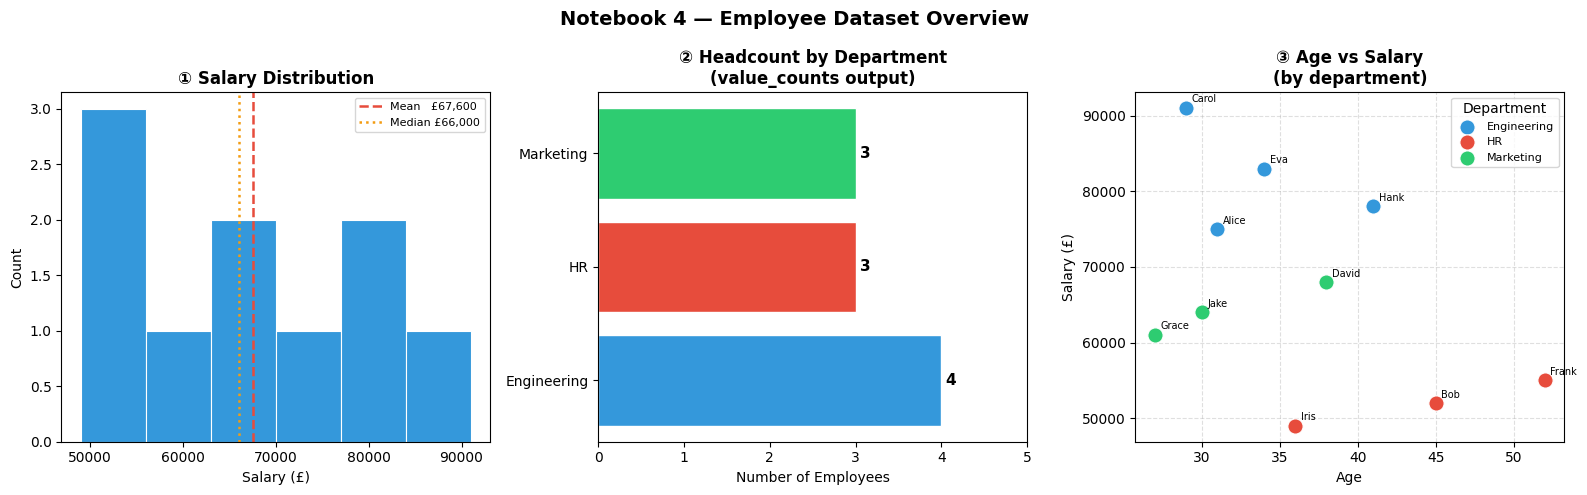


📊 Reading the panels:
  ① The histogram shows salaries spread roughly between £49k and £91k.
     The mean (red dashed) and median (orange dotted) are close together,
     suggesting no strong skew in our small dataset.
  ② Engineering has the most employees (4), HR and Marketing have 3 each.
     This mirrors the value_counts() output from Section 5 exactly.
  ③ The scatter suggests Engineering employees (blue) tend to earn more
     than HR (red) and Marketing (green) — and there is a weak positive
     trend between age and salary within Engineering.



In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))   # 1 row, 3 columns of subplots
fig.suptitle("Notebook 4 — Employee Dataset Overview",
             fontsize=14, fontweight="bold")

# ── Colour palette: one distinct colour per department ────────────────────────
dept_colours = {"Engineering": "#3498db", "HR": "#e74c3c", "Marketing": "#2ecc71"}

# ════════ Panel 1: Salary Distribution — Histogram ═══════════════════════════
ax1 = axes[0]

ax1.hist(
    df["salary"],          # the Series to plot
    bins=6,                # number of equal-width bins
    color="#3498db",       # bar fill colour
    edgecolor="white",     # white borders between bars
    linewidth=0.8
)

# Vertical lines for mean and median so we can see skew at a glance
ax1.axvline(df["salary"].mean(),   color="#e74c3c", linestyle="--",
            linewidth=1.8, label=f"Mean   £{df['salary'].mean():,.0f}")
ax1.axvline(df["salary"].median(), color="#f39c12", linestyle=":",
            linewidth=1.8, label=f"Median £{df['salary'].median():,.0f}")

ax1.set_title("① Salary Distribution", fontweight="bold")
ax1.set_xlabel("Salary (£)")
ax1.set_ylabel("Count")
ax1.legend(fontsize=8)

# ════════ Panel 2: Headcount by Department — Horizontal Bar ══════════════════
ax2 = axes[1]

dept_vc = df["department"].value_counts()   # Series: dept → count (sorted descending)
bar_cols = [dept_colours[d] for d in dept_vc.index]  # match each dept to its colour

bars = ax2.barh(
    dept_vc.index,      # y-axis: department names
    dept_vc.values,     # x-axis: counts
    color=bar_cols,
    edgecolor="white"
)

# Annotate each bar with its count value
for bar in bars:
    ax2.text(
        bar.get_width() + 0.05,   # x: just past the bar end
        bar.get_y() + bar.get_height() / 2,  # y: vertically centred
        str(int(bar.get_width())),
        va="center", fontsize=11, fontweight="bold"
    )

ax2.set_title("② Headcount by Department\n(value_counts output)", fontweight="bold")
ax2.set_xlabel("Number of Employees")
ax2.set_xlim(0, dept_vc.max() + 1)    # add space for the count annotations

# ════════ Panel 3: Age vs Salary — Scatter coloured by department ═════════════
ax3 = axes[2]

for dept, group in df.groupby("department"):   # split df into one sub-df per department
    ax3.scatter(
        group["age"],            # x-axis: age
        group["salary"],         # y-axis: salary
        label=dept,
        color=dept_colours[dept],
        s=120,                   # marker size in points²
        edgecolors="white",
        linewidth=0.8,
        zorder=3                 # draw on top of grid
    )

# Label each point with the employee's name
for _, row in df.iterrows():   # .iterrows() yields (index, Series) pairs
    ax3.annotate(
        row["name"],
        xy=(row["age"], row["salary"]),
        xytext=(4, 4),                      # offset in points
        textcoords="offset points",
        fontsize=7
    )

ax3.set_title("③ Age vs Salary\n(by department)", fontweight="bold")
ax3.set_xlabel("Age")
ax3.set_ylabel("Salary (£)")
ax3.legend(title="Department", fontsize=8)
ax3.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("""
📊 Reading the panels:
  ① The histogram shows salaries spread roughly between £49k and £91k.
     The mean (red dashed) and median (orange dotted) are close together,
     suggesting no strong skew in our small dataset.
  ② Engineering has the most employees (4), HR and Marketing have 3 each.
     This mirrors the value_counts() output from Section 5 exactly.
  ③ The scatter suggests Engineering employees (blue) tend to earn more
     than HR (red) and Marketing (green) — and there is a weak positive
     trend between age and salary within Engineering.
""")

---
## ✅ Notebook Summary & Key Takeaways

| Concept | Core rule | Gotcha to remember |
|---------|-----------|--------------------|
| **DataFrame** | Dictionary of NumPy arrays with a shared index | `.values` gives you back the raw NumPy array |
| **Series** | 1-D labelled array — one column of a DataFrame | Selecting `df['col']` → Series; `df[['col']]` → DataFrame |
| **Creating a DF** | From dict-of-lists, list-of-dicts, or NumPy array | All must have equal-length columns |
| **`head` / `tail`** | First / last N rows — quick visual check | Default N is 5 |
| **`info()`** | Non-null counts + dtypes — flags missing data | Run this immediately on any new dataset |
| **`describe()`** | Stats for numeric cols; `include='all'` for everything | std tells you the spread; compare mean vs median for skew |
| **`value_counts()`** | Frequency count for a categorical column | Normalise=True gives proportions instead of counts |
| **`pd.read_csv`** | Loads a CSV file into a DataFrame | Use `nrows=` to sample huge files before loading all |
| **`df.to_csv`** | Saves a DataFrame to a CSV file | Always set `index=False` unless you want the row numbers in the file |
| **dtypes** | Each column has one dtype — `object` = string | Use `category` dtype for low-cardinality string columns to save memory |

---
